In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

print("Setup Complete")

Setup Complete


In [2]:
FIG_DIR = Path("reports/figures")
TABLE_DIR = Path("reports/tables")

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Folders are ready")

Folders are ready


In [4]:
df = pd.read_csv("saudi_data_jobs_cleaned.csv")

print("Data loaded successfully")
df.head()

Data loaded successfully


,job_id,job_title,company,city,role_type,experience_level,skills,tools,source,job_link,date_collected,notes,city_cleaned,experience_category,role_category
0,1,Data Analyst,ALESAYI HOLDING,Jeddah,Data Analyst,Entry level / 3 years,"customer data analysis, operational performanc...","Excel, PowerPoint, dashboards",LinkedIn,https://sa.linkedin.com/jobs/view/data-analyst...,2026-06-30,Customer experience data analyst role in autom...,Jeddah,Entry Level,Data Analysis
1,2,Geological Data Scientist,Maaden Barrick Copper Company,Mahd Adh Dhahab,Data Scientist,Entry level / 2-5 years,"geological data management, data quality manag...","SQL, Python, Power BI, Tableau, relational dat...",LinkedIn,https://sa.linkedin.com/jobs/view/geological-d...,2026-06-30,Mining sector data science role. Focuses on ge...,Mahd Adh Dhahab,Entry Level,Data Science
2,3,Data Analyst,PrimeGate for Communications and IT,Riyadh,Data Analyst,Entry level,"data analysis, insights generation, dashboardi...","SQL, Power BI, Tableau, Looker, Excel, Python,...",LinkedIn,https://sa.linkedin.com/jobs/view/data-analyst...,2026-06-30,Entry-level data analyst role for Madinaty Sup...,Riyadh,Entry Level,Data Analysis
3,4,Analyst Pricing Analytics and Insights,Schneider Electric,Saudi Arabia,Business / Pricing Analytics,Entry level,"pricing analytics, data analysis, data interpr...","data visualization, dashboards, charts, reports",LinkedIn,https://sa.linkedin.com/jobs/view/analyst-pric...,2026-06-30,Entry-level pricing analytics role. Focuses on...,Not specified,Entry Level,Data Analysis
4,5,Power BI Developer,Acuative Middle East,Jeddah,BI / Power BI Developer,Mid-level,"Power BI dashboard development, business intel...","Power BI Desktop, Power BI Service, DAX, Power...",LinkedIn,https://sa.linkedin.com/jobs/view/power-bi-dev...,2026-06-30,Mid-level Power BI Developer role in Jeddah. F...,Jeddah,Mid-Level,BI


In [5]:
df[["job_title", "role_category", "experience_level", "experience_category", "tools", "skills"]].head(10)

,job_title,role_category,experience_level,experience_category,tools,skills
0,Data Analyst,Data Analysis,Entry level / 3 years,Entry Level,"Excel, PowerPoint, dashboards","customer data analysis, operational performanc..."
1,Geological Data Scientist,Data Science,Entry level / 2-5 years,Entry Level,"SQL, Python, Power BI, Tableau, relational dat...","geological data management, data quality manag..."
2,Data Analyst,Data Analysis,Entry level,Entry Level,"SQL, Power BI, Tableau, Looker, Excel, Python,...","data analysis, insights generation, dashboardi..."
3,Analyst Pricing Analytics and Insights,Data Analysis,Entry level,Entry Level,"data visualization, dashboards, charts, reports","pricing analytics, data analysis, data interpr..."
4,Power BI Developer,BI,Mid-level,Mid-Level,"Power BI Desktop, Power BI Service, DAX, Power...","Power BI dashboard development, business intel..."
5,2026 KSA Analyst Program - Data and AI Analyst,AI,Assistant level / Analyst Program,Entry Level,"Python, Java, TensorFlow, PyTorch, MATLAB, Tab...","AI model development, machine learning, data a..."
6,Data Scientist I,Data Science,Entry level / 0-2 years,Entry Level,"SQL, Python, LLMs, RAG, Generative AI, machine...","fraud detection, AML analytics, generative AI ..."
7,Specialist Operations Performance,Other,Assistant level / 2+ years,Entry Level,"Excel, Power BI, SQL, project management tools...","internal reporting, external reporting, data a..."
8,Data Analyst Fraud Protection,Data Analysis,Mid-level,Mid-Level,"Python, pandas, NumPy, databases, Plotly, Dash...","fraud behavior analysis, suspicious event anal..."
9,Junior Digital Marketing Analyst,Other,Entry level / 0-2 years,Entry Level,"GA4, Meta Ads Manager, Google Ads, Snapchat Ad...","digital marketing analytics, campaign performa..."


In [6]:
experience_counts = df["experience_category"].value_counts()

experience_counts

,count
experience_category,
Entry Level,12
Mid-Level,11
Internship,2


In [7]:
experience_summary = experience_counts.reset_index()

experience_summary.columns = ["experience_category", "job_count"]

experience_summary

,experience_category,job_count
0,Entry Level,12
1,Mid-Level,11
2,Internship,2


In [8]:
experience_summary.to_csv(TABLE_DIR / "experience_category_counts.csv", index=False)

print("Saved:", TABLE_DIR / "experience_category_counts.csv")

Saved: reports/tables/experience_category_counts.csv


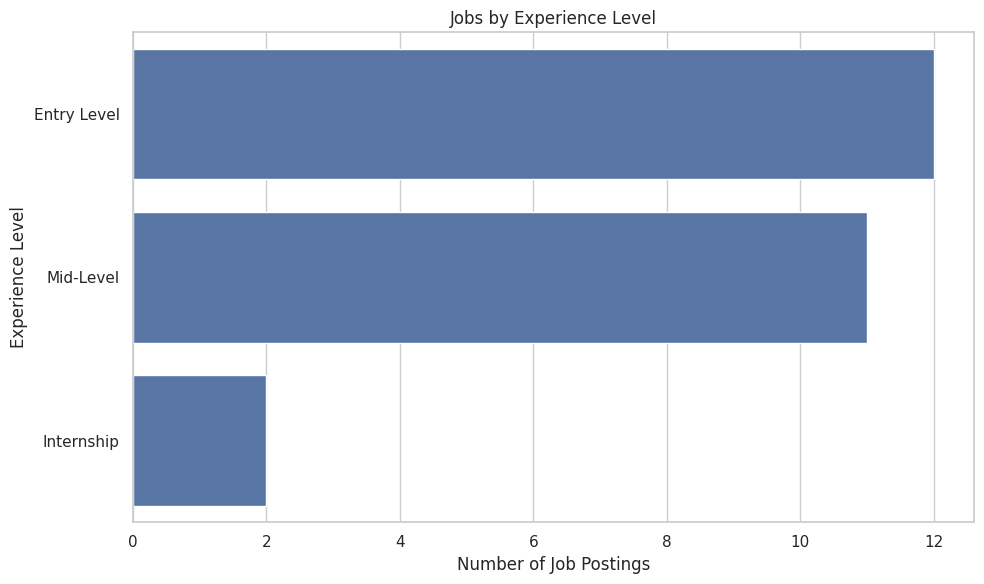

In [9]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=experience_summary,
    x="job_count",
    y="experience_category"
)

plt.title("Jobs by Experience Level")
plt.xlabel("Number of Job Postings")
plt.ylabel("Experience Level")
plt.tight_layout()

plt.savefig(FIG_DIR / "jobs_by_experience_level_bar_chart.png", dpi=300, bbox_inches="tight")

plt.show()

In [10]:
experience_summary["percentage"] = (
    experience_summary["job_count"] / experience_summary["job_count"].sum() * 100
).round(1)

experience_summary

,experience_category,job_count,percentage
0,Entry Level,12,48.0
1,Mid-Level,11,44.0
2,Internship,2,8.0


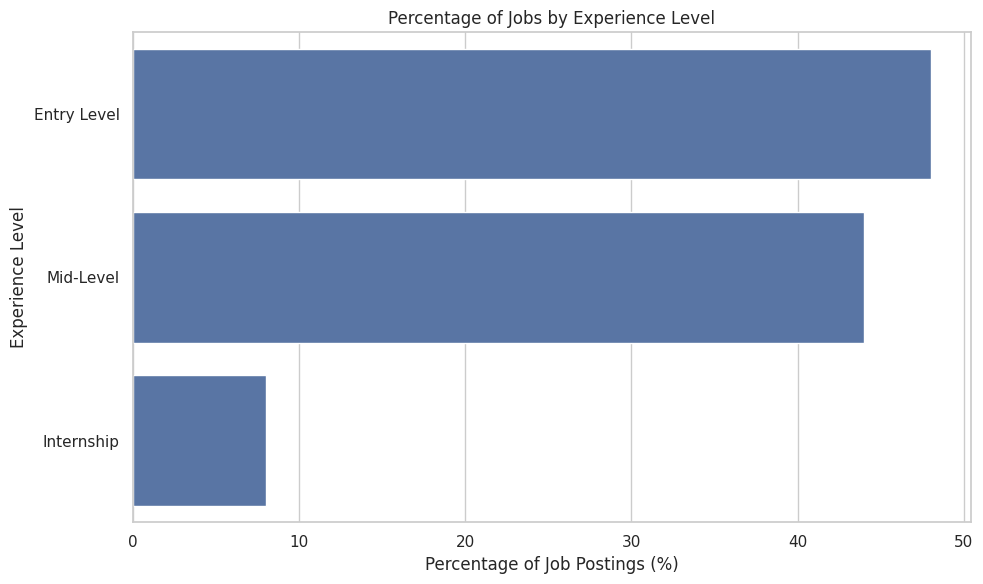

In [11]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=experience_summary,
    x="percentage",
    y="experience_category"
)

plt.title("Percentage of Jobs by Experience Level")
plt.xlabel("Percentage of Job Postings (%)")
plt.ylabel("Experience Level")
plt.tight_layout()

plt.savefig(FIG_DIR / "experience_level_percentage_bar_chart.png", dpi=300, bbox_inches="tight")

plt.show()

In [12]:
experience_role_table = pd.crosstab(
    df["experience_category"],
    df["role_category"]
)

experience_role_table

role_category,AI,BI,Data Analysis,Data Science,Governance,Other
experience_category,,,,,,
Entry Level,1,1,4,2,1,3
Internship,2,0,0,0,0,0
Mid-Level,1,2,5,0,1,2


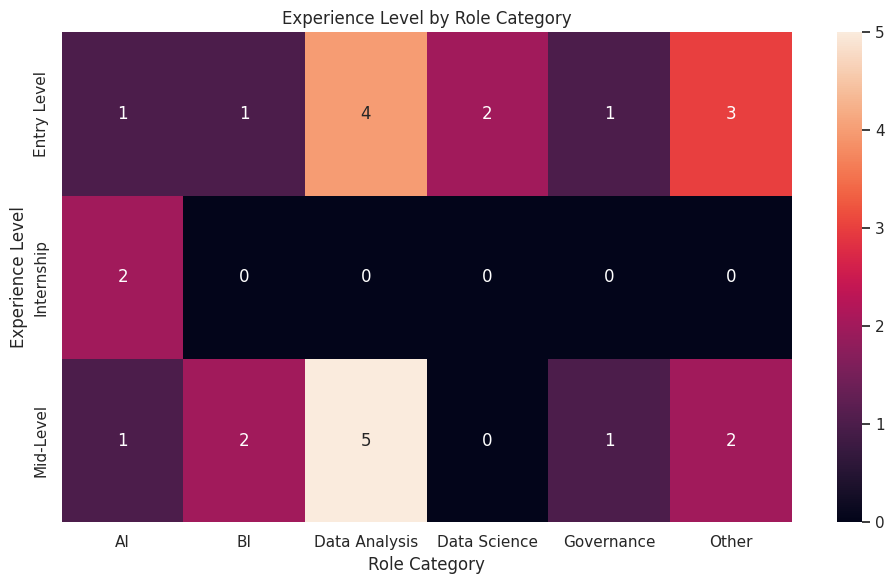

In [13]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    experience_role_table,
    annot=True,
    fmt="d"
)

plt.title("Experience Level by Role Category")
plt.xlabel("Role Category")
plt.ylabel("Experience Level")
plt.tight_layout()

plt.savefig(FIG_DIR / "experience_by_role_category_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [14]:
tools_long = df.copy()

tools_long["tools"] = tools_long["tools"].fillna("")

tools_long["tool"] = tools_long["tools"].str.split(r",|;|\|")

tools_long = tools_long.explode("tool")

tools_long["tool"] = tools_long["tool"].astype(str).str.strip()

tools_long = tools_long[tools_long["tool"] != ""].copy()

tools_long[["job_title", "experience_category", "tool"]].head(15)

,job_title,experience_category,tool
0,Data Analyst,Entry Level,Excel
0,Data Analyst,Entry Level,PowerPoint
0,Data Analyst,Entry Level,dashboards
1,Geological Data Scientist,Entry Level,SQL
1,Geological Data Scientist,Entry Level,Python
1,Geological Data Scientist,Entry Level,Power BI
1,Geological Data Scientist,Entry Level,Tableau
1,Geological Data Scientist,Entry Level,relational databases
1,Geological Data Scientist,Entry Level,Acquire
1,Geological Data Scientist,Entry Level,DataShed


In [15]:
def normalize_tool(tool):
    tool = str(tool).strip()
    tool = " ".join(tool.split())
    key = tool.lower().replace("-", " ")

    mapping = {
        "powerbi": "Power BI",
        "power bi": "Power BI",
        "ms power bi": "Power BI",
        "microsoft power bi": "Power BI",

        "tableau": "Tableau",

        "excel": "Excel",
        "ms excel": "Excel",
        "microsoft excel": "Excel",

        "sql": "SQL",
        "mysql": "MySQL",

        "python": "Python",
        "r": "R",

        "pytorch": "PyTorch",

        "powerpoint": "PowerPoint",
        "power point": "PowerPoint",
        "ms powerpoint": "PowerPoint",

        "dashboard": "Dashboards",
        "dashboards": "Dashboards",

        "bi tools": "BI tools",
        "business intelligence tools": "BI tools"
    }

    return mapping.get(key, tool)

tools_long["tool_normalized"] = tools_long["tool"].apply(normalize_tool)

tools_long[["tool", "tool_normalized"]].drop_duplicates().head(30)

,tool,tool_normalized
0,Excel,Excel
0,PowerPoint,PowerPoint
0,dashboards,Dashboards
1,SQL,SQL
1,Python,Python
1,Power BI,Power BI
1,Tableau,Tableau
1,relational databases,relational databases
1,Acquire,Acquire
1,DataShed,DataShed


In [16]:
top_tools = tools_long["tool_normalized"].value_counts().reset_index()

top_tools.columns = ["tool", "count"]

top_tools.head(10)

,tool,count
0,SQL,12
1,Python,11
2,Excel,10
3,Power BI,9
4,Tableau,7
5,Dashboards,4
6,BI tools,4
7,PyTorch,3
8,PowerPoint,3
9,R,3


In [17]:
top_10_tools = top_tools.head(10)["tool"].tolist()

tools_by_experience = pd.crosstab(
    tools_long["tool_normalized"],
    tools_long["experience_category"]
)

tools_by_experience = tools_by_experience.loc[top_10_tools]

tools_by_experience

experience_category,Entry Level,Internship,Mid-Level
tool_normalized,,,
SQL,5,0,7
Python,4,0,7
Excel,6,0,4
Power BI,4,0,5
Tableau,4,0,3
Dashboards,4,0,0
BI tools,2,0,2
PyTorch,1,0,2
PowerPoint,3,0,0


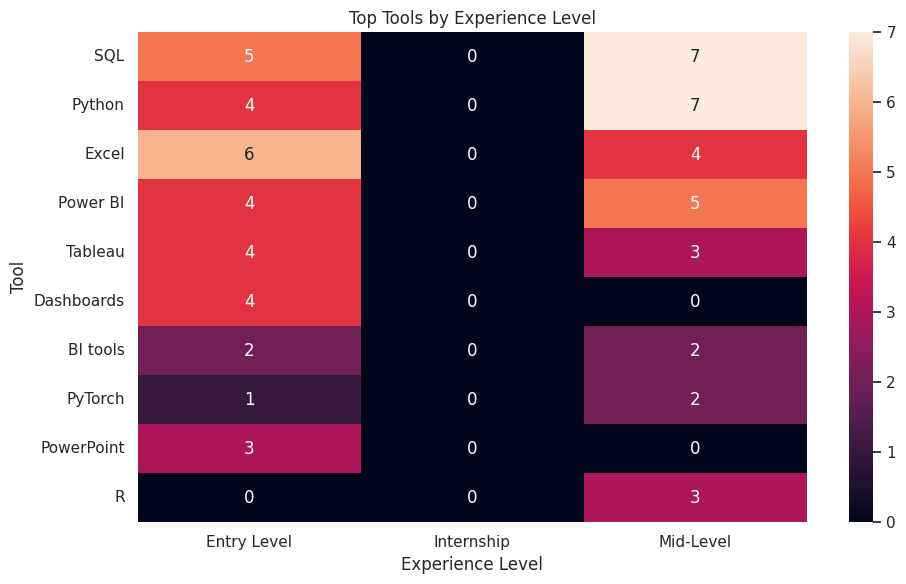

In [18]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    tools_by_experience,
    annot=True,
    fmt="d"
)

plt.title("Top Tools by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Tool")
plt.tight_layout()

plt.savefig(FIG_DIR / "top_tools_by_experience_day11_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [19]:
skills_long = df.copy()

skills_long["skills"] = skills_long["skills"].fillna("")

skills_long["skill"] = skills_long["skills"].str.split(r",|;|\|")

skills_long = skills_long.explode("skill")

skills_long["skill"] = skills_long["skill"].astype(str).str.strip()

skills_long = skills_long[skills_long["skill"] != ""].copy()

skills_long[["job_title", "experience_category", "skill"]].head(15)

,job_title,experience_category,skill
0,Data Analyst,Entry Level,customer data analysis
0,Data Analyst,Entry Level,operational performance analysis
0,Data Analyst,Entry Level,data accuracy
0,Data Analyst,Entry Level,reporting
0,Data Analyst,Entry Level,dashboarding
0,Data Analyst,Entry Level,customer experience analysis
0,Data Analyst,Entry Level,complaint monitoring
0,Data Analyst,Entry Level,campaign performance tracking
0,Data Analyst,Entry Level,business insights
1,Geological Data Scientist,Entry Level,geological data management


In [20]:
def normalize_skill(skill):
    skill = str(skill).strip()
    skill = " ".join(skill.split())
    key = skill.lower().replace("-", " ")

    mapping = {
        "data analysis": "Data Analysis",
        "analysis": "Data Analysis",
        "reporting": "Reporting",
        "reports": "Reporting",
        "dashboard": "Dashboarding",
        "dashboards": "Dashboarding",
        "dashboard development": "Dashboarding",
        "data visualization": "Data Visualization",
        "visualization": "Data Visualization",
        "problem solving": "Problem Solving",
        "communication": "Communication",
        "stakeholder communication": "Stakeholder Communication",
        "data validation": "Data Validation",
        "data quality": "Data Quality",
        "machine learning": "Machine Learning",
        "ml": "Machine Learning",
        "business intelligence": "Business Intelligence",
        "bi": "Business Intelligence"
    }

    return mapping.get(key, skill)

skills_long["skill_normalized"] = skills_long["skill"].apply(normalize_skill)

skills_long[["skill", "skill_normalized"]].drop_duplicates().head(30)

,skill,skill_normalized
0,customer data analysis,customer data analysis
0,operational performance analysis,operational performance analysis
0,data accuracy,data accuracy
0,reporting,Reporting
0,dashboarding,dashboarding
0,customer experience analysis,customer experience analysis
0,complaint monitoring,complaint monitoring
0,campaign performance tracking,campaign performance tracking
0,business insights,business insights
1,geological data management,geological data management


In [21]:
top_skills = skills_long["skill_normalized"].value_counts().reset_index()

top_skills.columns = ["skill", "count"]

top_skills.head(10)

,skill,count
0,trend analysis,9
1,Data Validation,8
2,Data Analysis,8
3,data governance,6
4,Reporting,6
5,Problem Solving,6
6,Dashboarding,5
7,data accuracy,5
8,dashboarding,5
9,data integrity,5


In [22]:
top_10_skills = top_skills.head(10)["skill"].tolist()

skills_by_experience = pd.crosstab(
    skills_long["skill_normalized"],
    skills_long["experience_category"]
)

skills_by_experience = skills_by_experience.loc[top_10_skills]

skills_by_experience

experience_category,Entry Level,Internship,Mid-Level
skill_normalized,,,
trend analysis,4,0,5
Data Validation,4,0,4
Data Analysis,5,1,2
data governance,3,0,3
Reporting,5,0,1
Problem Solving,3,1,2
Dashboarding,2,0,3
data accuracy,4,0,1
dashboarding,5,0,0


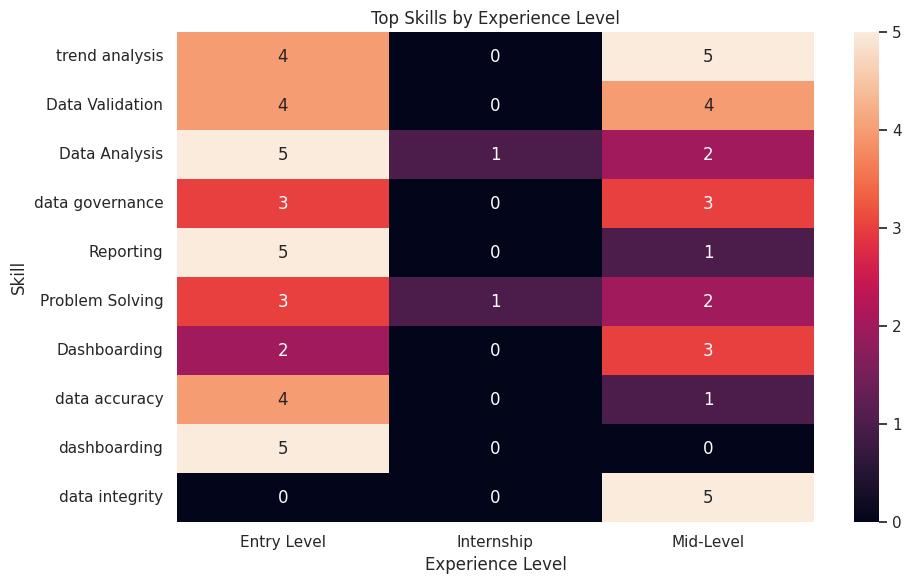

In [23]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    skills_by_experience,
    annot=True,
    fmt="d"
)

plt.title("Top Skills by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Skill")
plt.tight_layout()

plt.savefig(FIG_DIR / "top_skills_by_experience_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [24]:
experience_scatter = experience_summary.copy()

experience_scatter["rank"] = range(1, len(experience_scatter) + 1)

experience_scatter

,experience_category,job_count,percentage,rank
0,Entry Level,12,48.0,1
1,Mid-Level,11,44.0,2
2,Internship,2,8.0,3


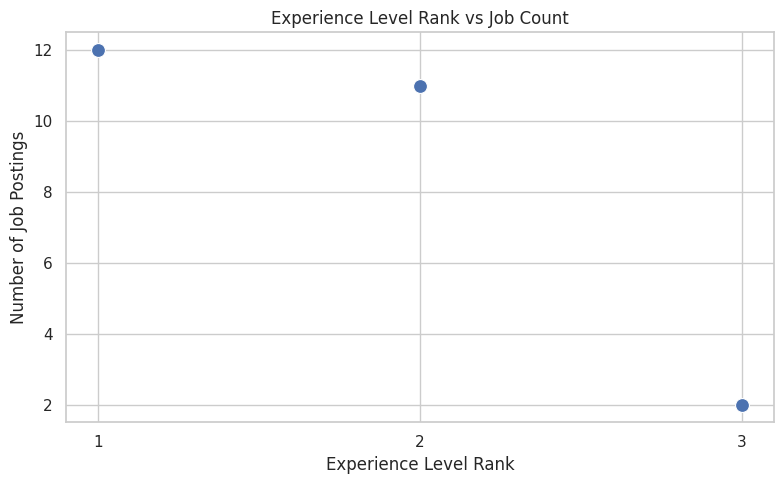

In [25]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=experience_scatter,
    x="rank",
    y="job_count",
    s=100
)

plt.title("Experience Level Rank vs Job Count")
plt.xlabel("Experience Level Rank")
plt.ylabel("Number of Job Postings")
plt.xticks(experience_scatter["rank"])
plt.tight_layout()

plt.savefig(FIG_DIR / "experience_rank_scatter_plot.png", dpi=300, bbox_inches="tight")

plt.show()

In [26]:
experience_scatter[["rank", "experience_category", "job_count", "percentage"]]

,rank,experience_category,job_count,percentage
0,1,Entry Level,12,48.0
1,2,Mid-Level,11,44.0
2,3,Internship,2,8.0


In [27]:
experience_role_table.to_csv(TABLE_DIR / "experience_by_role_category.csv")
tools_by_experience.to_csv(TABLE_DIR / "tools_by_experience_day11.csv")
skills_by_experience.to_csv(TABLE_DIR / "skills_by_experience.csv")
experience_scatter.to_csv(TABLE_DIR / "experience_scatter_table.csv", index=False)

print("Day 11 tables saved.")

Day 11 tables saved.


In [28]:
top_experience = experience_summary.iloc[0]["experience_category"]
top_experience_count = experience_summary.iloc[0]["job_count"]
top_experience_percentage = experience_summary.iloc[0]["percentage"]

print("Day 11 Insight:")
print(f"The most common experience category in the dataset is {top_experience}.")
print(f"It appeared in {top_experience_count} job postings, representing {top_experience_percentage}% of the dataset.")

print("\nThe heatmaps help compare how role categories, tools, and skills differ across experience levels.")
print("This is useful for understanding what entry-level data roles require compared to mid-level and internship roles.")

Day 11 Insight:
The most common experience category in the dataset is Entry Level.
It appeared in 12 job postings, representing 48.0% of the dataset.

The heatmaps help compare how role categories, tools, and skills differ across experience levels.
This is useful for understanding what entry-level data roles require compared to mid-level and internship roles.


In [29]:
saved_figures = list(FIG_DIR.glob("*.png"))

print("Saved figures:")
for fig in saved_figures:
    print(fig)

Saved figures:
reports/figures/experience_level_percentage_bar_chart.png
reports/figures/jobs_by_experience_level_bar_chart.png
reports/figures/experience_by_role_category_heatmap.png
reports/figures/experience_rank_scatter_plot.png
reports/figures/top_tools_by_experience_day11_heatmap.png
reports/figures/top_skills_by_experience_heatmap.png


In [30]:
saved_tables = list(TABLE_DIR.glob("*.csv"))

print("Saved tables:")
for table in saved_tables:
    print(table)

Saved tables:
reports/tables/experience_category_counts.csv
reports/tables/tools_by_experience_day11.csv
reports/tables/experience_by_role_category.csv
reports/tables/experience_scatter_table.csv
reports/tables/skills_by_experience.csv


## Day 11: Experience Category Analysis

Today I analyzed the cleaned `experience_category` column to better understand the experience levels required in Saudi data-related job postings.

Completed:
- Counted job postings by experience level.
- Calculated the percentage of each experience category.
- Compared experience levels with role categories.
- Analyzed top tools by experience level.
- Analyzed top skills by experience level.
- Created heatmaps to compare experience levels with roles, tools, and skills.
- Created a scatter plot for experience rank and job count.
- Saved charts and analysis tables.

Main takeaway:
The experience category analysis helps identify what entry-level, mid-level, and internship data roles require. It also shows that early-career data roles often need a mix of SQL, Python, Excel, dashboards, reporting, and analysis skills.